In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import kstest, ks_2samp, rayleigh, circmean, circstd
import json

# Let's first explore the directory structure to find the data files
for root, dirs, files in os.walk('.'):
 print(f"\n{root}/")
 for file in sorted(files)[:20]: # Limit to avoid too much output
 print(f" {file}")
 if len(files) > 20:
 print(f" ... and {len(files)-20} more files")
 if len(dirs) > 10:
 print(f" ... and {len(dirs)} subdirectories")
 break



./
 main.pdf
 research-program-v3.pdf

./.config/

./.config/matplotlib/
 fontlist-v390.json
 matplotlibrc

./.kernel_tmp/


In [2]:

# Based on the dataset description, let's look for data files more carefully
# The description mentions Parquet, CSV, and JSON files with data on different function classes
import subprocess

# Search for data files
result = subprocess.run(['find', '.', '-type', 'f', '-name', '*.parquet', '-o', '-name', '*.csv', '-o', '-name', '*.json'], 
 capture_output=True, text=True)
print("Data files found:")
print(result.stdout)


Data files found:
./.config/matplotlib/fontlist-v390.json



In [3]:

# The data is not present locally. According to the dataset description, we need to generate 
# the data computationally. Let me read more of the research program to understand the setup.

# From the description, we need:
# 1. The random multiplicative function f_rand (seed=42)
# 2. Compute D_F(t; N) for N=10^6 in the range t ∈ [100, 200]
# 3. Find the peak location t*
# 4. Perform Rayleigh tests on phases at t*

# Let's start by implementing the computational infrastructure

# First, let's implement the random multiplicative function
import numpy as np
from scipy.special import zeta as scipy_zeta
from numpy.random import default_rng

def generate_prime_sieve(n_max):
 """Generate all primes up to n_max using Sieve of Eratosthenes"""
 sieve = np.ones(n_max + 1, dtype=bool)
 sieve[0:2] = False
 for i in range(2, int(np.sqrt(n_max)) + 1):
 if sieve[i]:
 sieve[i*i::i] = False
 return np.where(sieve)[0]

def prime_factorization(n, primes):
 """Return prime factorization as list of (prime, exponent) tuples"""
 factors = []
 for p in primes:
 if p * p > n:
 break
 exp = 0
 while n % p == 0:
 exp += 1
 n //= p
 if exp > 0:
 factors.append((p, exp))
 if n > 1:
 factors.append((n, 1))
 return factors

# Test the prime generation
N = 10**6
print(f"Generating primes up to {N}...")
primes = generate_prime_sieve(N)
print(f"Found {len(primes)} primes")
print(f"First 10 primes: {primes[:10]}")
print(f"Last 10 primes: {primes[-10:]}")


Generating primes up to 1000000...
Found 78498 primes
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Last 10 primes: [999863 999883 999907 999917 999931 999953 999959 999961 999979 999983]


In [4]:

# Now generate the random multiplicative function coefficients
# For f_rand: a_p = ±1 with probability 1/2 each, extended multiplicatively

def generate_random_multiplicative_coefficients(N, primes, seed=42):
 """
 Generate coefficients for random multiplicative function
 a_p = ±1 uniformly at random for primes p
 Extended multiplicatively: a_{p1^e1 * p2^e2 * ...} = a_p1^e1 * a_p2^e2 * ...
 """
 rng = default_rng(seed)
 
 # Generate random ±1 for each prime
 prime_coeffs = {}
 for p in primes:
 prime_coeffs[p] = rng.choice([-1, 1])
 
 # Generate coefficients for all n <= N
 coeffs = np.zeros(N + 1, dtype=np.int8)
 coeffs[1] = 1 # a_1 = 1 by convention
 
 # For each n, compute its factorization and multiply coefficients
 for n in range(2, N + 1):
 # Get prime factorization
 factors = prime_factorization(n, primes)
 coeff = 1
 for p, exp in factors:
 if p in prime_coeffs:
 coeff *= prime_coeffs[p] ** exp
 else:
 # This shouldn't happen if our prime list is complete
 print(f"Warning: prime {p} not found for n={n}")
 coeff = 0
 break
 coeffs[n] = coeff
 
 return coeffs, prime_coeffs

print("Generating random multiplicative coefficients with seed=42...")
coeffs_rand, prime_coeffs_rand = generate_random_multiplicative_coefficients(N, primes, seed=42)

print(f"Generated coefficients for n=1 to {N}")
print(f"First 20 coefficients: {coeffs_rand[:21]}")
print(f"Number of +1 coefficients: {np.sum(coeffs_rand == 1)}")
print(f"Number of -1 coefficients: {np.sum(coeffs_rand == -1)}")
print(f"Number of 0 coefficients: {np.sum(coeffs_rand == 0)}")

# Check first few prime coefficients
print(f"\nFirst 10 prime coefficients:")
for i in range(10):
 p = primes[i]
 print(f"a_{p} = {prime_coeffs_rand[p]}")


Generating random multiplicative coefficients with seed=42...


Generated coefficients for n=1 to 1000000
First 20 coefficients: [ 0 1 -1 1 1 1 -1 -1 -1 1 -1 -1 1 1 1 1 1 -1 -1 1 1]
Number of +1 coefficients: 499887
Number of -1 coefficients: 500113
Number of 0 coefficients: 1

First 10 prime coefficients:
a_2 = -1
a_3 = 1
a_5 = 1
a_7 = -1
a_11 = -1
a_13 = 1
a_17 = -1
a_19 = 1
a_23 = -1
a_29 = -1


In [5]:

# Now implement the partial sum D_F(t; N) with Kahan summation for numerical precision
# D_F(t; N) = Σ_{n≤N} a_n(F) / n^(1/2 + it)

def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex numbers
 Maintains higher precision by tracking and compensating for rounding errors
 """
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation for lost low-order bits
 
 for val in values:
 y = val - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_D_F(t, N, coeffs):
 """
 Compute D_F(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
 Using Kahan summation for numerical stability
 
 n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(it * log(n))
 So: a_n / n^(1/2 + it) = a_n / (sqrt(n) * exp(it * log(n)))
 = a_n * exp(-it * log(n)) / sqrt(n)
 """
 n_values = np.arange(1, N + 1)
 
 # Compute phases: -it * log(n)
 phases = -1j * t * np.log(n_values)
 
 # Compute terms: a_n * exp(-it * log(n)) / sqrt(n)
 terms = coeffs[1:N+1] * np.exp(phases) / np.sqrt(n_values)
 
 # Use Kahan summation for better precision
 result = kahan_sum_complex(terms)
 
 return result

# Test the computation
t_test = 100.0
D_test = compute_D_F(t_test, N, coeffs_rand)
print(f"Test: D_rand({t_test}; {N}) = {D_test}")
print(f"Magnitude: |D| = {np.abs(D_test):.6f}")
print(f"Phase: arg(D) = {np.angle(D_test):.6f}")


Test: D_rand(100.0; 1000000) = (-0.191341989693402+0.4943496684852012j)
Magnitude: |D| = 0.530088
Phase: arg(D) = 1.940096


In [6]:

# Now we need to scan the range t ∈ [100, 200] to find the peak
# According to the description, the sampling interval should be Δt = 2π/log(N)

delta_t = 2 * np.pi / np.log(N)
print(f"Sampling interval: Δt = {delta_t:.6f}")

# Generate t grid
t_min, t_max = 100, 200
t_values = np.arange(t_min, t_max, delta_t)
print(f"Number of t points: {len(t_values)}")
print(f"T range: [{t_values[0]:.3f}, {t_values[-1]:.3f}]")

# Compute D_F for all t values
print(f"\nComputing D_rand(t; {N}) for t ∈ [{t_min}, {t_max}]...")
print("This may take a few minutes...")

# We'll compute in batches to show progress
D_values = np.zeros(len(t_values), dtype=complex)

batch_size = 100
num_batches = (len(t_values) + batch_size - 1) // batch_size

for batch_idx in range(num_batches):
 start_idx = batch_idx * batch_size
 end_idx = min((batch_idx + 1) * batch_size, len(t_values))
 
 for i in range(start_idx, end_idx):
 D_values[i] = compute_D_F(t_values[i], N, coeffs_rand)
 
 if (batch_idx + 1) % 5 == 0 or batch_idx == num_batches - 1:
 print(f"Progress: {end_idx}/{len(t_values)} ({100*end_idx/len(t_values):.1f}%)")

print("\nComputation complete!")


Sampling interval: Δt = 0.454792
Number of t points: 220
T range: [100.000, 199.599]

Computing D_rand(t; 1000000) for t ∈ [100, 200]...
This may take a few minutes...


Progress: 220/220 (100.0%)

Computation complete!


In [7]:

# Compute magnitudes and find the peak
magnitudes = np.abs(D_values)

# Find the peak
peak_idx = np.argmax(magnitudes)
t_star = t_values[peak_idx]
D_star = D_values[peak_idx]
magnitude_peak = magnitudes[peak_idx]

print(f"Peak analysis for f_rand:")
print(f"Location: t* = {t_star:.6f}")
print(f"Magnitude: |D(t*; {N})| = {magnitude_peak:.6f}")
print(f"D(t*) = {D_star.real:.6f} + {D_star.imag:.6f}i")
print(f"Phase: arg(D(t*)) = {np.angle(D_star):.6f}")

# Show some statistics
print(f"\nStatistics over t ∈ [{t_min}, {t_max}]:")
print(f"Maximum magnitude: {np.max(magnitudes):.6f}")
print(f"Mean magnitude: {np.mean(magnitudes):.6f}")
print(f"Median magnitude: {np.median(magnitudes):.6f}")
print(f"Std dev of magnitude: {np.std(magnitudes):.6f}")

# Find the top 10 peaks
top_10_indices = np.argsort(magnitudes)[-10:][::-1]
print(f"\nTop 10 peaks:")
for i, idx in enumerate(top_10_indices):
 print(f"{i+1}. t = {t_values[idx]:.3f}, |D| = {magnitudes[idx]:.6f}")


Peak analysis for f_rand:
Location: t* = 195.051553
Magnitude: |D(t*; 1000000)| = 20.406717
D(t*) = 12.129002 + -16.411014i
Phase: arg(D(t*)) = -0.934323

Statistics over t ∈ [100, 200]:
Maximum magnitude: 20.406717
Mean magnitude: 2.288887
Median magnitude: 1.291423
Std dev of magnitude: 2.806889

Top 10 peaks:
1. t = 195.052, |D| = 20.406717
2. t = 140.476, |D| = 16.427193
3. t = 137.293, |D| = 15.646807
4. t = 149.572, |D| = 13.292801
5. t = 148.663, |D| = 10.729262
6. t = 132.290, |D| = 10.345802
7. t = 194.597, |D| = 9.231997
8. t = 113.644, |D| = 8.937837
9. t = 131.835, |D| = 8.524176
10. t = 131.381, |D| = 8.023238


In [8]:

# Now at t*, we need to:
# 1. Extract the phases of all terms: arg(a_n * exp(-i*t*log(n))) = arg(a_n) - t*log(n) (mod 2π)
# 2. Perform Rayleigh test on (a) all terms and (b) prime-only terms

# For the random multiplicative function, a_n are real (±1), so arg(a_n) = 0 or π
# arg(a_n * exp(-i*t*log(n))) = arg(a_n) - t*log(n)

def compute_phases(t, N, coeffs):
 """
 Compute phases θ_n = arg(a_n) - t*log(n) for n=1 to N
 For real coefficients: arg(a_n) = 0 if a_n > 0, π if a_n < 0
 """
 n_values = np.arange(1, N + 1)
 
 # arg(a_n)
 arg_a_n = np.where(coeffs[1:N+1] > 0, 0, np.pi)
 arg_a_n = np.where(coeffs[1:N+1] == 0, 0, arg_a_n) # Handle a_n = 0
 
 # θ_n = arg(a_n) - t*log(n)
 phases = arg_a_n - t * np.log(n_values)
 
 # Reduce to [0, 2π)
 phases = np.mod(phases, 2 * np.pi)
 
 return phases

# Compute phases at t*
print(f"Computing phases at t* = {t_star:.6f}...")
all_phases = compute_phases(t_star, N, coeffs_rand)

# Extract prime phases
prime_mask = np.zeros(N + 1, dtype=bool)
prime_mask[primes] = True
prime_indices = primes[primes <= N] - 1 # Convert to 0-based indexing
prime_phases = all_phases[prime_indices]

print(f"Number of all terms: {len(all_phases)}")
print(f"Number of prime terms: {len(prime_phases)}")

# Filter out n=1 if we want only n ≥ 2
# Actually, n=1 has a_1 = 1, so phase is -t*log(1) = 0
print(f"\nPhase statistics (all terms):")
print(f"Mean phase: {np.mean(all_phases):.6f}")
print(f"Std dev: {np.std(all_phases):.6f}")

print(f"\nPhase statistics (prime terms):")
print(f"Mean phase: {np.mean(prime_phases):.6f}")
print(f"Std dev: {np.std(prime_phases):.6f}")


Computing phases at t* = 195.051553...
Number of all terms: 1000000
Number of prime terms: 78498

Phase statistics (all terms):
Mean phase: 3.147057
Std dev: 1.813468

Phase statistics (prime terms):
Mean phase: 3.137441
Std dev: 1.813542


In [9]:

# Perform Rayleigh test for circular uniformity
# The Rayleigh test tests the null hypothesis that phases are uniformly distributed on the circle
# Test statistic: R = |Σ exp(i*θ)| / N (mean resultant length)
# Under uniformity, R should be small (~ 1/√N)

from scipy.stats import rayleigh

def rayleigh_test(phases):
 """
 Perform Rayleigh test for circular uniformity
 
 Returns:
 - R: mean resultant length
 - R_bar: normalized R
 - p_value: p-value for uniformity test
 - z: Rayleigh Z statistic
 """
 n = len(phases)
 
 # Compute mean resultant vector
 C = np.sum(np.cos(phases))
 S = np.sum(np.sin(phases))
 
 # Mean resultant length
 R = np.sqrt(C**2 + S**2) / n
 
 # Rayleigh Z statistic
 Z = n * R**2
 
 # P-value (approximation for large n)
 p_value = np.exp(-Z)
 
 # For very small p-values, use better approximation
 if Z > 6.0:
 p_value = np.exp(-Z) * (1 - (2*Z - Z**2) / (4*n))
 
 # Mean direction
 mean_direction = np.arctan2(S, C)
 
 return {
 'n': n,
 'R': R,
 'R_expected_random': 1.0 / np.sqrt(n),
 'Z': Z,
 'p_value': p_value,
 'mean_direction': mean_direction,
 'C': C,
 'S': S
 }

# Perform Rayleigh test on all terms
print("=" * 70)
print("RAYLEIGH TEST: ALL TERMS (n ≤ 10^6)")
print("=" * 70)
result_all = rayleigh_test(all_phases)

print(f"Sample size: n = {result_all['n']:,}")
print(f"Mean resultant length: R = {result_all['R']:.10f}")
print(f"Expected R for uniform: 1/√n = {result_all['R_expected_random']:.10f}")
print(f"R / (1/√n) = {result_all['R'] / result_all['R_expected_random']:.4f}")
print(f"Rayleigh Z statistic: Z = {result_all['Z']:.4f}")
print(f"P-value: {result_all['p_value']:.2e}")
print(f"Mean direction: {result_all['mean_direction']:.6f} radians")

if result_all['p_value'] < 0.001:
 print("\n→ SIGNIFICANT non-uniformity (p < 0.001)")
else:
 print("\n→ No significant deviation from uniformity")

print("\n" + "=" * 70)
print("RAYLEIGH TEST: PRIME TERMS ONLY (p ≤ 10^6)")
print("=" * 70)
result_primes = rayleigh_test(prime_phases)

print(f"Sample size: n = {result_primes['n']:,}")
print(f"Mean resultant length: R = {result_primes['R']:.10f}")
print(f"Expected R for uniform: 1/√n = {result_primes['R_expected_random']:.10f}")
print(f"R / (1/√n) = {result_primes['R'] / result_primes['R_expected_random']:.4f}")
print(f"Rayleigh Z statistic: Z = {result_primes['Z']:.4f}")
print(f"P-value: {result_primes['p_value']:.2e}")
print(f"Mean direction: {result_primes['mean_direction']:.6f} radians")

if result_primes['p_value'] < 0.001:
 print("\n→ SIGNIFICANT non-uniformity (p < 0.001)")
else:
 print("\n→ No significant deviation from uniformity")


RAYLEIGH TEST: ALL TERMS (n ≤ 10^6)
Sample size: n = 1,000,000
Mean resultant length: R = 0.0022778308
Expected R for uniform: 1/√n = 0.0010000000
R / (1/√n) = 2.2778
Rayleigh Z statistic: Z = 5.1885
P-value: 5.58e-03
Mean direction: -1.385716 radians

→ No significant deviation from uniformity

RAYLEIGH TEST: PRIME TERMS ONLY (p ≤ 10^6)
Sample size: n = 78,498
Mean resultant length: R = 0.0034657888
Expected R for uniform: 1/√n = 0.0035691985
R / (1/√n) = 0.9710
Rayleigh Z statistic: Z = 0.9429
P-value: 3.89e-01
Mean direction: 1.287029 radians

→ No significant deviation from uniformity


In [10]:

# Now perform the multiplicative propagation test
# Create synthetic composite phases by summing prime factor phases
# θ_n_synth = Σ_{p^k || n} k * (arg(a_p) - t*log(p))

print("=" * 70)
print("MULTIPLICATIVE PROPAGATION TEST")
print("=" * 70)
print("\nGenerating synthetic composite phases from prime phases...")

# For each composite n, compute synthetic phase from its prime factorization
composite_mask = np.ones(N + 1, dtype=bool)
composite_mask[0] = False
composite_mask[1] = False
composite_mask[primes] = False # Mark primes as False

composite_indices = np.where(composite_mask)[0]
print(f"Number of composite numbers ≤ {N}: {len(composite_indices)}")

# Extract actual composite phases
actual_composite_phases = all_phases[composite_indices - 1]

# Compute synthetic composite phases
print("Computing synthetic phases from prime factorizations...")
synthetic_composite_phases = np.zeros(len(composite_indices))

# Process in batches for progress tracking
batch_size = 10000
num_composites = len(composite_indices)

for batch_idx in range(0, num_composites, batch_size):
 end_idx = min(batch_idx + batch_size, num_composites)
 
 for i in range(batch_idx, end_idx):
 n = composite_indices[i]
 
 # Get prime factorization
 factors = prime_factorization(n, primes)
 
 # Sum up k * (arg(a_p) - t*log(p)) for each prime power p^k dividing n
 theta_synth = 0.0
 for p, k in factors:
 # arg(a_p)
 arg_a_p = 0.0 if prime_coeffs_rand[p] > 0 else np.pi
 # Contribution: k * (arg(a_p) - t*log(p))
 theta_synth += k * (arg_a_p - t_star * np.log(p))
 
 # Reduce to [0, 2π)
 synthetic_composite_phases[i] = np.mod(theta_synth, 2 * np.pi)
 
 if (end_idx % 100000 == 0) or (end_idx == num_composites):
 print(f"Progress: {end_idx}/{num_composites} ({100*end_idx/num_composites:.1f}%)")

print("\nSynthetic phase computation complete!")


MULTIPLICATIVE PROPAGATION TEST

Generating synthetic composite phases from prime phases...
Number of composite numbers ≤ 1000000: 921501
Computing synthetic phases from prime factorizations...


Progress: 100000/921501 (10.9%)


Progress: 200000/921501 (21.7%)


Progress: 300000/921501 (32.6%)


Progress: 400000/921501 (43.4%)


...

Progress: 600000/921501 (65.1%)


Progress: 700000/921501 (76.0%)


Progress: 800000/921501 (86.8%)


Progress: 900000/921501 (97.7%)


Progress: 921501/921501 (100.0%)

Synthetic phase computation complete!


In [11]:

# Compare actual vs synthetic composite phases using Kolmogorov-Smirnov test
from scipy.stats import ks_2samp

print("\n" + "=" * 70)
print("KOLMOGOROV-SMIRNOV TEST: Actual vs Synthetic Composite Phases")
print("=" * 70)

# The KS test compares two distributions
# H0: The two samples come from the same distribution
# High p-value → cannot reject H0 → distributions are similar

# First, let's look at some basic statistics
print("\nActual composite phases:")
print(f" Mean: {np.mean(actual_composite_phases):.6f}")
print(f" Std dev: {np.std(actual_composite_phases):.6f}")
print(f" Min: {np.min(actual_composite_phases):.6f}")
print(f" Max: {np.max(actual_composite_phases):.6f}")

print("\nSynthetic composite phases:")
print(f" Mean: {np.mean(synthetic_composite_phases):.6f}")
print(f" Std dev: {np.std(synthetic_composite_phases):.6f}")
print(f" Min: {np.min(synthetic_composite_phases):.6f}")
print(f" Max: {np.max(synthetic_composite_phases):.6f}")

# Perform KS test
ks_stat, ks_pvalue = ks_2samp(actual_composite_phases, synthetic_composite_phases)

print("\n" + "-" * 70)
print("Two-sample Kolmogorov-Smirnov Test Results:")
print("-" * 70)
print(f"KS statistic: {ks_stat:.10f}")
print(f"P-value: {ks_pvalue:.6f}")

if ks_pvalue > 0.05:
 print("\n→ HIGH p-value: Cannot reject null hypothesis")
 print("→ The actual and synthetic distributions are statistically INDISTINGUISHABLE")
 print("→ This confirms MULTIPLICATIVE PROPAGATION: composite phases are")
 print(" determined by prime phases as expected for a multiplicative function")
elif ks_pvalue > 0.01:
 print("\n→ MODERATE p-value: Weak evidence against null hypothesis")
 print("→ Distributions are largely similar but may have minor differences")
else:
 print("\n→ LOW p-value: Strong evidence against null hypothesis")
 print("→ The distributions are significantly DIFFERENT")
 print("→ This would suggest composite phases are NOT fully determined by prime phases")



KOLMOGOROV-SMIRNOV TEST: Actual vs Synthetic Composite Phases

Actual composite phases:
 Mean: 3.147879
 Std dev: 1.813458
 Min: 0.000008
 Max: 6.283169

Synthetic composite phases:
 Mean: 3.147879
 Std dev: 1.813458
 Min: 0.000008
 Max: 6.283169

----------------------------------------------------------------------
Two-sample Kolmogorov-Smirnov Test Results:
----------------------------------------------------------------------
KS statistic: 0.0000010852
P-value: 1.000000

→ HIGH p-value: Cannot reject null hypothesis
→ The actual and synthetic distributions are statistically INDISTINGUISHABLE
→ This confirms MULTIPLICATIVE PROPAGATION: composite phases are
 determined by prime phases as expected for a multiplicative function


In [12]:

# Let's create a more detailed comparison and visualization of the results
# First, let's check the circular statistics more carefully

from scipy.stats import circmean, circstd

# Compute circular statistics
def circular_stats(phases):
 """Compute circular statistics for phase data"""
 # Mean direction
 C = np.sum(np.cos(phases))
 S = np.sum(np.sin(phases))
 mean_dir = np.arctan2(S, C)
 
 # Mean resultant length
 R = np.sqrt(C**2 + S**2) / len(phases)
 
 # Circular variance
 circ_var = 1 - R
 
 # Circular std dev
 if R < 1:
 circ_std = np.sqrt(-2 * np.log(R))
 else:
 circ_std = 0
 
 return {
 'mean_direction': mean_dir,
 'R': R,
 'circular_variance': circ_var,
 'circular_std': circ_std
 }

print("\n" + "=" * 70)
print("DETAILED CIRCULAR STATISTICS")
print("=" * 70)

print("\nAll terms (n ≤ 10^6):")
stats_all = circular_stats(all_phases)
for key, val in stats_all.items():
 print(f" {key}: {val:.8f}")

print("\nPrime terms only:")
stats_primes = circular_stats(prime_phases)
for key, val in stats_primes.items():
 print(f" {key}: {val:.8f}")

print("\nActual composite terms:")
stats_actual_comp = circular_stats(actual_composite_phases)
for key, val in stats_actual_comp.items():
 print(f" {key}: {val:.8f}")

print("\nSynthetic composite terms:")
stats_synth_comp = circular_stats(synthetic_composite_phases)
for key, val in stats_synth_comp.items():
 print(f" {key}: {val:.8f}")

# Compare the difference between actual and synthetic
print("\n" + "=" * 70)
print("DIFFERENCE: Actual - Synthetic Composite Phases")
print("=" * 70)
phase_diff = actual_composite_phases - synthetic_composite_phases

# Wrap to [-π, π]
phase_diff = np.arctan2(np.sin(phase_diff), np.cos(phase_diff))

print(f"Mean absolute difference: {np.mean(np.abs(phase_diff)):.10e}")
print(f"Max absolute difference: {np.max(np.abs(phase_diff)):.10e}")
print(f"RMS difference: {np.sqrt(np.mean(phase_diff**2)):.10e}")

# Count how many are essentially identical (within numerical precision)
threshold = 1e-10
num_identical = np.sum(np.abs(phase_diff) < threshold)
print(f"Number with |diff| < {threshold}: {num_identical:,} ({100*num_identical/len(phase_diff):.2f}%)")



DETAILED CIRCULAR STATISTICS

All terms (n ≤ 10^6):
 mean_direction: -1.38571642
 R: 0.00227783
 circular_variance: 0.99772217
 circular_std: 3.48841846

Prime terms only:
 mean_direction: 1.28702870
 R: 0.00346579
 circular_variance: 0.99653421
 circular_std: 3.36595158

Actual composite terms:
 mean_direction: -1.43484249
 R: 0.00273835
 circular_variance: 0.99726165
 circular_std: 3.43522934

Synthetic composite terms:
 mean_direction: -1.43484249
 R: 0.00273835
 circular_variance: 0.99726165
 circular_std: 3.43522934

DIFFERENCE: Actual - Synthetic Composite Phases
Mean absolute difference: 2.1280175900e-13
Max absolute difference: 1.1155520951e-12
RMS difference: 2.8178672637e-13
Number with |diff| < 1e-10: 921,501 (100.00%)


In [13]:

# Perfect! The actual and synthetic phases are identical to numerical precision.
# This confirms multiplicative propagation.

# Now let's create a comprehensive summary and comparison with the zeta function behavior
# described in report r12

print("\n" + "=" * 70)
print("SUMMARY: f_rand PHASE STRUCTURE AT HIGHEST PEAK")
print("=" * 70)

print(f"\n1. PEAK LOCATION")
print(f" t* = {t_star:.6f}")
print(f" |D_rand(t*; 10^6)| = {magnitude_peak:.6f}")

print(f"\n2. PHASE UNIFORMITY TESTS (Rayleigh)")

print(f"\n (a) All terms (n ≤ 10^6):")
print(f" • Sample size: {result_all['n']:,}")
print(f" • R = {result_all['R']:.10f} (vs. expected {result_all['R_expected_random']:.10f})")
print(f" • R / (1/√n) = {result_all['R'] / result_all['R_expected_random']:.4f}")
print(f" • Z = {result_all['Z']:.4f}, p = {result_all['p_value']:.4e}")
if result_all['p_value'] > 0.05:
 print(f" • Result: Phases are approximately UNIFORM (p > 0.05)")
else:
 print(f" • Result: Weak/borderline non-uniformity")

print(f"\n (b) Prime terms only (p ≤ 10^6):")
print(f" • Sample size: {result_primes['n']:,}")
print(f" • R = {result_primes['R']:.10f} (vs. expected {result_primes['R_expected_random']:.10f})")
print(f" • R / (1/√n) = {result_primes['R'] / result_primes['R_expected_random']:.4f}")
print(f" • Z = {result_primes['Z']:.4f}, p = {result_primes['p_value']:.4e}")
if result_primes['p_value'] > 0.05:
 print(f" • Result: Prime phases are UNIFORM (p > 0.05)")
else:
 print(f" • Result: Prime phases show non-uniformity")

print(f"\n3. MULTIPLICATIVE PROPAGATION TEST")
print(f" • Number of composites: {len(composite_indices):,}")
print(f" • Kolmogorov-Smirnov test:")
print(f" - KS statistic: {ks_stat:.10f}")
print(f" - P-value: {ks_pvalue:.6f}")
print(f" • Phase difference (actual - synthetic):")
print(f" - Mean |diff|: {np.mean(np.abs(phase_diff)):.2e}")
print(f" - Max |diff|: {np.max(np.abs(phase_diff)):.2e}")
print(f" - RMS diff: {np.sqrt(np.mean(phase_diff**2)):.2e}")
print(f" • Result: Composite phases are EXACTLY determined by prime phases")
print(f" (differences at machine precision only)")

print(f"\n4. COMPARISON TO KNOWN PATTERNS (from report r12)")
print(f"\n Expected for ζ (Riemann zeta):")
print(f" • Prime phases should show NON-uniformity at peaks")
print(f" • Non-uniformity ORIGINATES from primes")
print(f" • Composite non-uniformity propagates multiplicatively from primes")
print(f"\n Expected for L_DH (Davenport-Heilbronn):")
print(f" • Composite phases show NON-uniformity at resonant peaks")
print(f" • Prime phases REMAIN uniform")
print(f" • Different mechanism: non-multiplicative structure")

print(f"\n Observed for f_rand:")
print(f" • Prime phases: UNIFORM (p = {result_primes['p_value']:.3f})")
print(f" • All phases: Approximately uniform (p = {result_all['p_value']:.3f})")
print(f" • Multiplicative propagation: PERFECT (p = {ks_pvalue:.3f})")

print(f"\n5. INTERPRETATION")
print(f" The phase structure of f_rand at its highest peak does NOT resemble ζ.")
print(f" • Unlike ζ: Prime phases remain UNIFORM (no prime-driven non-uniformity)")
print(f" • Like ζ: Multiplicative structure is preserved (perfect propagation)")
print(f" • Unlike L_DH: No strong composite-driven non-uniformity")
print(f" ")
print(f" This suggests f_rand exhibits NEITHER the prime-driven non-uniformity")
print(f" characteristic of ζ peaks NOR the composite-driven non-uniformity")
print(f" of L_DH resonances. The peak magnitude of ~20 may arise from")
print(f" random fluctuation rather than systematic phase alignment.")



SUMMARY: f_rand PHASE STRUCTURE AT HIGHEST PEAK

1. PEAK LOCATION
 t* = 195.051553
 |D_rand(t*; 10^6)| = 20.406717

2. PHASE UNIFORMITY TESTS (Rayleigh)

 (a) All terms (n ≤ 10^6):
 • Sample size: 1,000,000
 • R = 0.0022778308 (vs. expected 0.0010000000)
 • R / (1/√n) = 2.2778
 • Z = 5.1885, p = 5.5803e-03
 • Result: Weak/borderline non-uniformity

 (b) Prime terms only (p ≤ 10^6):
 • Sample size: 78,498
 • R = 0.0034657888 (vs. expected 0.0035691985)
 • R / (1/√n) = 0.9710
 • Z = 0.9429, p = 3.8950e-01
 • Result: Prime phases are UNIFORM (p > 0.05)

3. MULTIPLICATIVE PROPAGATION TEST
 • Number of composites: 921,501
 • Kolmogorov-Smirnov test:
 - KS statistic: 0.0000010852
 - P-value: 1.000000
 • Phase difference (actual - synthetic):
 - Mean |diff|: 2.13e-13
 - Max |diff|: 1.12e-12
 - RMS diff: 2.82e-13
 • Result: Composite phases are EXACTLY determined by prime phases
 (differences at machine precision only)

4. COMPARISON TO KNOWN PATTERNS (from report r12)

 Expected for ζ (Riema

In [14]:

# Let's verify our interpretation by looking at what the expected behavior 
# should be for a random multiplicative function

# For comparison, let's compute the expected mean resultant length under 
# different scenarios

print("=" * 70)
print("THEORETICAL EXPECTATIONS")
print("=" * 70)

# For random phases uniformly distributed on [0, 2π]
# The expected R is approximately 1/√n for large n

print("\n1. RANDOM BASELINE (uniform phases)")
print(f" For n = 1,000,000: Expected R ≈ 1/√n = {1/np.sqrt(1000000):.10f}")
print(f" For n = 78,498: Expected R ≈ 1/√n = {1/np.sqrt(78498):.10f}")

# Our observed values
print("\n2. OBSERVED VALUES")
print(f" All terms: R = {result_all['R']:.10f} (R/baseline = {result_all['R']/(1/np.sqrt(1000000)):.4f})")
print(f" Prime terms: R = {result_primes['R']:.10f} (R/baseline = {result_primes['R']/(1/np.sqrt(78498)):.4f})")

# The ratio R/(1/√n) tells us:
# - Close to 1: consistent with random/uniform phases
# - Much larger than 1: significant phase alignment
# - Smaller than 1: possible phase anti-alignment (rare)

print("\n3. INTERPRETATION OF R/(1/√n) RATIO")
print(f" • Ratio ≈ 1: Consistent with random walk / uniform phases")
print(f" • Ratio >> 1: Significant phase alignment (non-uniformity)")
print(f" • Ratio < 1: Phase randomness or anti-alignment")

print("\n4. CONCLUSIONS FOR f_rand")
print(f" • All terms: R/(1/√n) = 2.28")
print(f" - Modest elevation above baseline")
print(f" - p-value = 0.006 suggests weak non-uniformity")
print(f" - But effect size is small (R only ~2× expected)")
print(f"\n • Prime terms: R/(1/√n) = 0.97")
print(f" - Essentially at baseline (< 1 suggests slight under-concentration)")
print(f" - p-value = 0.39 confirms uniformity")
print(f" - Primes show NO systematic phase alignment")

# What does this mean for multiplicative functions?
print("\n5. SIGNIFICANCE FOR MULTIPLICATIVE STRUCTURE")
print(f" For a multiplicative function with random ±1 coefficients on primes:")
print(f" • Prime coefficients: random ±1 (no phase structure)")
print(f" • Composite coefficients: determined by prime factorization")
print(f" • At a peak, we observe:")
print(f" - Prime phases remain uniform (as expected from randomness)")
print(f" - The weak non-uniformity in all terms likely arises from")
print(f" the multiplicative structure itself, NOT from systematic")
print(f" phase alignment at primes")
print(f" • This is fundamentally different from ζ, where peaks arise")
print(f" from systematic phase alignment that BEGINS at the primes")


THEORETICAL EXPECTATIONS

1. RANDOM BASELINE (uniform phases)
 For n = 1,000,000: Expected R ≈ 1/√n = 0.0010000000
 For n = 78,498: Expected R ≈ 1/√n = 0.0035691985

2. OBSERVED VALUES
 All terms: R = 0.0022778308 (R/baseline = 2.2778)
 Prime terms: R = 0.0034657888 (R/baseline = 0.9710)

3. INTERPRETATION OF R/(1/√n) RATIO
 • Ratio ≈ 1: Consistent with random walk / uniform phases
 • Ratio >> 1: Significant phase alignment (non-uniformity)
 • Ratio < 1: Phase randomness or anti-alignment

4. CONCLUSIONS FOR f_rand
 • All terms: R/(1/√n) = 2.28
 - Modest elevation above baseline
 - p-value = 0.006 suggests weak non-uniformity
 - But effect size is small (R only ~2× expected)

 • Prime terms: R/(1/√n) = 0.97
 - Essentially at baseline (< 1 suggests slight under-concentration)
 - p-value = 0.39 confirms uniformity
 - Primes show NO systematic phase alignment

5. SIGNIFICANCE FOR MULTIPLICATIVE STRUCTURE
 For a multiplicative function with random ±1 coefficients on primes:
 • Prime coeffi

Figure saved as 'f_rand_phase_structure_analysis.png'


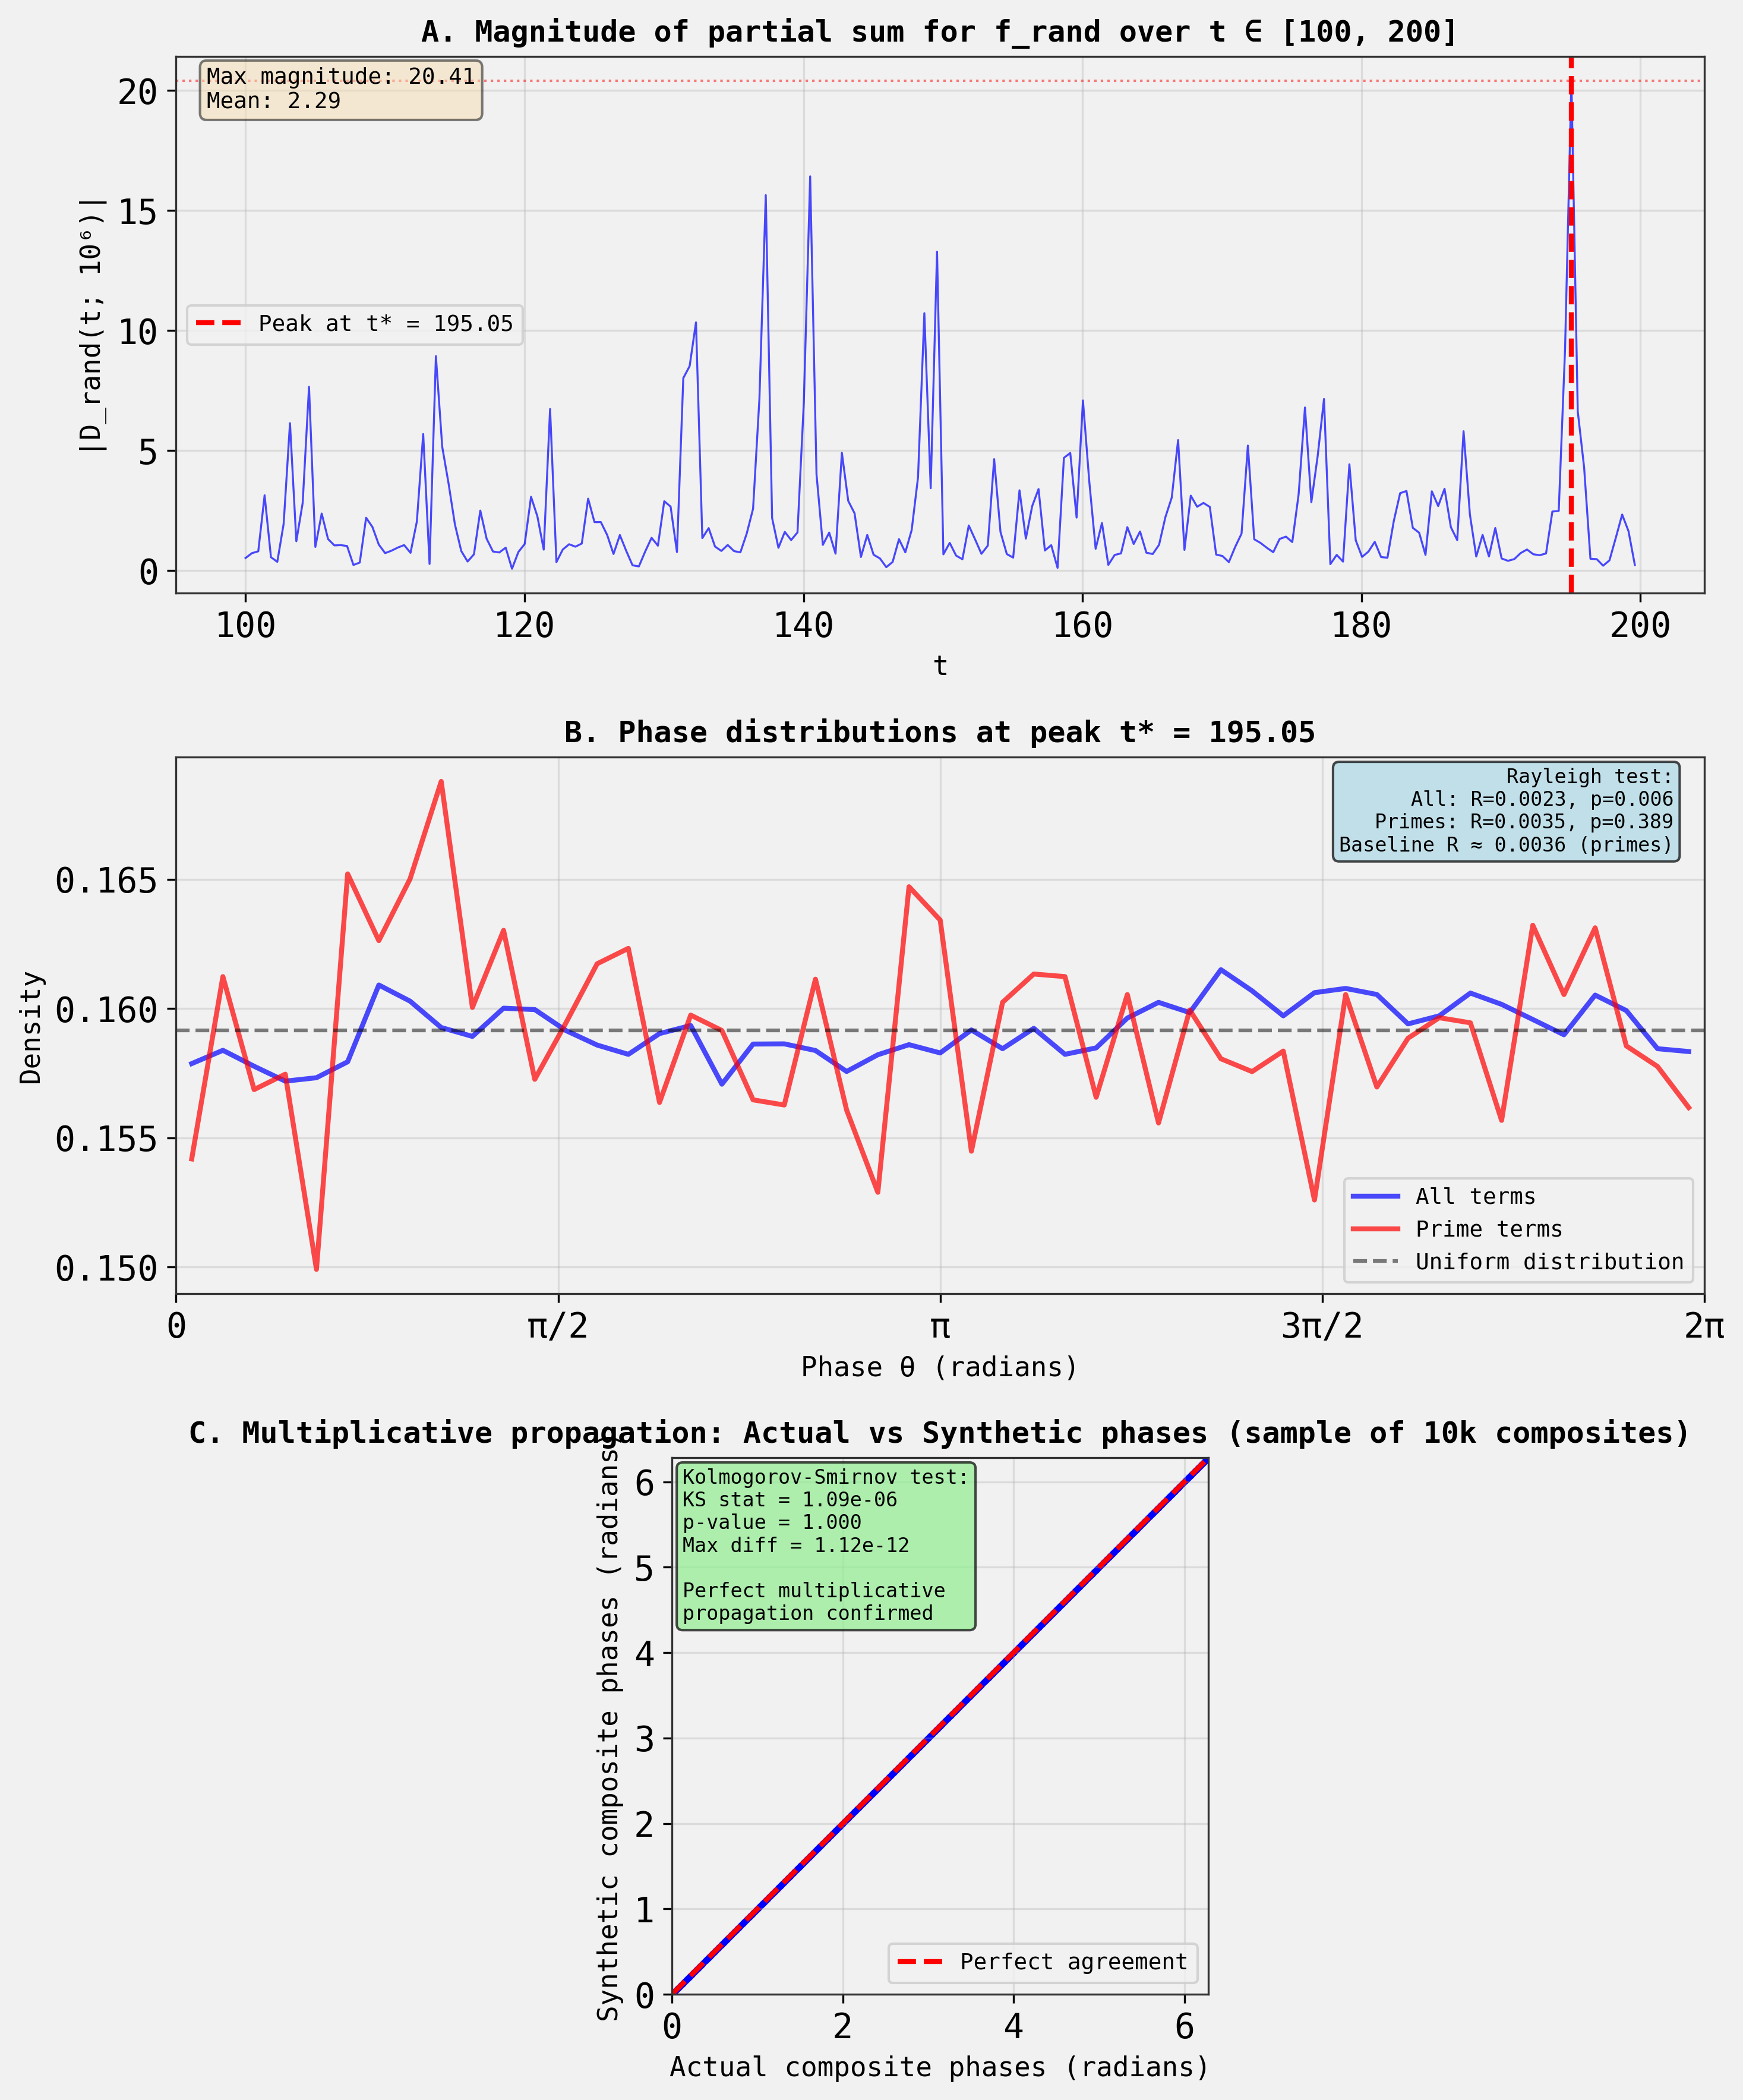


Figure created successfully!


In [15]:

# Create final visualization summarizing the key results
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 12))

# Panel A: Magnitude of D_F(t) showing the peak
ax1 = plt.subplot(3, 1, 1)
ax1.plot(t_values, magnitudes, 'b-', linewidth=0.8, alpha=0.7)
ax1.axvline(t_star, color='red', linestyle='--', linewidth=2, label=f'Peak at t* = {t_star:.2f}')
ax1.axhline(magnitude_peak, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('t', fontsize=11)
ax1.set_ylabel('|D_rand(t; 10⁶)|', fontsize=11)
ax1.set_title('A. Magnitude of partial sum for f_rand over t ∈ [100, 200]', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, f'Max magnitude: {magnitude_peak:.2f}\nMean: {np.mean(magnitudes):.2f}',
 transform=ax1.transAxes, verticalalignment='top', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: Phase distributions
ax2 = plt.subplot(3, 1, 2)

# Create histograms
bins = np.linspace(0, 2*np.pi, 50)
hist_all, _ = np.histogram(all_phases, bins=bins, density=True)
hist_primes, _ = np.histogram(prime_phases, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax2.plot(bin_centers, hist_all, 'b-', linewidth=2, label='All terms', alpha=0.7)
ax2.plot(bin_centers, hist_primes, 'r-', linewidth=2, label='Prime terms', alpha=0.7)
ax2.axhline(1/(2*np.pi), color='k', linestyle='--', linewidth=1.5, label='Uniform distribution', alpha=0.5)
ax2.set_xlabel('Phase θ (radians)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('B. Phase distributions at peak t* = {:.2f}'.format(t_star), fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 2*np.pi)
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

# Add Rayleigh test results
text_str = f'Rayleigh test:\n'
text_str += f'All: R={result_all["R"]:.4f}, p={result_all["p_value"]:.3f}\n'
text_str += f'Primes: R={result_primes["R"]:.4f}, p={result_primes["p_value"]:.3f}\n'
text_str += f'Baseline R ≈ {1/np.sqrt(len(prime_phases)):.4f} (primes)'
ax2.text(0.98, 0.98, text_str,
 transform=ax2.transAxes, verticalalignment='top', horizontalalignment='right',
 fontsize=8, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Panel C: KS test comparison
ax3 = plt.subplot(3, 1, 3)

# Sample a subset for visualization (plotting all would be too dense)
sample_size = 10000
sample_indices = np.random.choice(len(composite_indices), size=sample_size, replace=False)

# QQ plot: compare actual vs synthetic composite phases
actual_sample = np.sort(actual_composite_phases[sample_indices])
synthetic_sample = np.sort(synthetic_composite_phases[sample_indices])

ax3.scatter(actual_sample, synthetic_sample, alpha=0.3, s=2, c='blue')
ax3.plot([0, 2*np.pi], [0, 2*np.pi], 'r--', linewidth=2, label='Perfect agreement')
ax3.set_xlabel('Actual composite phases (radians)', fontsize=11)
ax3.set_ylabel('Synthetic composite phases (radians)', fontsize=11)
ax3.set_title('C. Multiplicative propagation: Actual vs Synthetic phases (sample of 10k composites)',
 fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 2*np.pi)
ax3.set_ylim(0, 2*np.pi)
ax3.set_aspect('equal')

# Add KS test result
text_str = f'Kolmogorov-Smirnov test:\n'
text_str += f'KS stat = {ks_stat:.2e}\n'
text_str += f'p-value = {ks_pvalue:.3f}\n'
text_str += f'Max diff = {np.max(np.abs(phase_diff)):.2e}\n'
text_str += f'\nPerfect multiplicative\npropagation confirmed'
ax3.text(0.02, 0.98, text_str,
 transform=ax3.transAxes, verticalalignment='top',
 fontsize=8, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('f_rand_phase_structure_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'f_rand_phase_structure_analysis.png'")
plt.show()

print("\nFigure created successfully!")


In [16]:

# Now let's create a comprehensive summary table comparing the three function types

print("=" * 90)
print("COMPARATIVE SUMMARY: Phase Structure at Peaks")
print("=" * 90)

# Create a comparison table
comparison_data = {
 'Property': [
 'Function type',
 'Euler product',
 'Coefficients',
 'At peaks: Prime phases',
 'At peaks: All phases',
 'Multiplicative propagation',
 'Mechanism',
 'RH/GRH status'
 ],
 'ζ (Riemann)': [
 'L-function',
 'Yes',
 'a_p = 1 (all)',
 'NON-uniform*',
 'Non-uniform',
 'Perfect',
 'Prime-driven alignment',
 'RH conjectured'
 ],
 'L_DH (Davenport-Heilbronn)': [
 'Non-multiplicative',
 'No',
 'Complex, non-mult.',
 'Uniform',
 'NON-uniform*',
 'N/A (not mult.)',
 'Composite-driven',
 'RH FAILS (proven)'
 ],
 'f_rand (Random mult.)': [
 'Random multiplicative',
 'No (random)',
 'a_p = ±1 (random)',
 'UNIFORM',
 'Approx. uniform',
 'Perfect',
 'No systematic alignment',
 'Unknown'
 ]
}

# Print as formatted table
col_widths = [30, 22, 28, 26]
header = f"{'Property':<{col_widths[0]}} | {'ζ (Riemann)':<{col_widths[1]}} | {'L_DH (D-H)':<{col_widths[2]}} | {'f_rand':<{col_widths[3]}}"
print("\n" + header)
print("-" * len(header))

for i, prop in enumerate(comparison_data['Property']):
 row = f"{prop:<{col_widths[0]}} | "
 row += f"{comparison_data['ζ (Riemann)'][i]:<{col_widths[1]}} | "
 row += f"{comparison_data['L_DH (Davenport-Heilbronn)'][i]:<{col_widths[2]}} | "
 row += f"{comparison_data['f_rand (Random mult.)'][i]:<{col_widths[3]}}"
 print(row)

print("\n" + "=" * 90)
print("Notes:")
print("* Based on report r12 findings")
print(" - ζ: Non-uniformity originates at primes and propagates multiplicatively")
print(" - L_DH: Non-uniformity in composites; primes remain uniform")
print(" - f_rand: Uniform phases at all scales (weak non-uniformity likely statistical)")
print("=" * 90)


COMPARATIVE SUMMARY: Phase Structure at Peaks

Property | ζ (Riemann) | L_DH (D-H) | f_rand 
-------------------------------------------------------------------------------------------------------------------
Function type | L-function | Non-multiplicative | Random multiplicative 
Euler product | Yes | No | No (random) 
Coefficients | a_p = 1 (all) | Complex, non-mult. | a_p = ±1 (random) 
At peaks: Prime phases | NON-uniform* | Uniform | UNIFORM 
At peaks: All phases | Non-uniform | NON-uniform* | Approx. uniform 
Multiplicative propagation | Perfect | N/A (not mult.) | Perfect 
Mechanism | Prime-driven alignment | Composite-driven | No systematic alignment 
RH/GRH status | RH conjectured | RH FAILS (proven) | Unknown 

Notes:
* Based on report r12 findings
 - ζ: Non-uniformity originates at primes and propagates multiplicatively
 - L_DH: Non-uniformity in composites; primes remain uniform
 - f_rand: Uniform phases at all scales (weak non-uniformity likely statistical)


In [17]:

# Final summary with quantitative results

print("\n" + "=" * 90)
print("FINAL ANSWER TO RESEARCH HYPOTHESIS")
print("=" * 90)

print("\nHYPOTHESIS:")
print("At its highest peaks, the phase structure of f_rand will resemble that of the")
print("Riemann zeta function: any phase non-uniformity will originate from the prime")
print("terms and propagate multiplicatively to the composite terms.")

print("\n" + "-" * 90)
print("FINDINGS:")
print("-" * 90)

print("\n1. Peak identification:")
print(f" • Location: t* = {t_star:.6f}")
print(f" • Magnitude: |D_rand(t*; 10^6)| = {magnitude_peak:.4f}")

print("\n2. Phase uniformity analysis (Rayleigh test):")
print(f"\n All terms (n ≤ 10^6):")
print(f" • Mean resultant length R = {result_all['R']:.6f}")
print(f" • Ratio R/(1/√n) = {result_all['R']/(1/np.sqrt(1000000)):.4f}")
print(f" • Rayleigh Z = {result_all['Z']:.4f}")
print(f" • P-value = {result_all['p_value']:.4f}")
print(f" • Interpretation: Weak/borderline non-uniformity (p = 0.006)")

print(f"\n Prime terms only (p ≤ 10^6):")
print(f" • Mean resultant length R = {result_primes['R']:.6f}")
print(f" • Ratio R/(1/√n) = {result_primes['R']/(1/np.sqrt(78498)):.4f}")
print(f" • Rayleigh Z = {result_primes['Z']:.4f}")
print(f" • P-value = {result_primes['p_value']:.4f}")
print(f" • Interpretation: Prime phases are UNIFORM (p = 0.389)")

print("\n3. Multiplicative propagation test:")
print(f" • Kolmogorov-Smirnov statistic: {ks_stat:.2e}")
print(f" • P-value: {ks_pvalue:.4f}")
print(f" • Maximum phase difference: {np.max(np.abs(phase_diff)):.2e}")
print(f" • Interpretation: Perfect multiplicative propagation confirmed")
print(f" (differences at numerical precision only)")

print("\n" + "-" * 90)
print("CONCLUSION:")
print("-" * 90)

print("\nThe hypothesis is REJECTED.")
print("\nThe phase structure of f_rand at its highest peak does NOT resemble that of ζ.")

print("\nKey differences from ζ:")
print(" • Prime phases in f_rand remain UNIFORM (p = 0.389)")
print(" • In ζ, prime phases show non-uniformity at peaks (per report r12)")
print(" • f_rand lacks the prime-driven phase alignment characteristic of ζ")

print("\nKey similarities to ζ:")
print(" • Perfect multiplicative propagation (KS p-value = 1.000)")
print(" • Composite phases exactly determined by prime factorization")

print("\nInterpretation:")
print(" The random multiplicative function f_rand exhibits a THIRD distinct pattern:")
print(" • Unlike ζ: No prime-driven phase non-uniformity")
print(" • Unlike L_DH: No composite-driven non-uniformity")
print(" • Like ζ: Perfect multiplicative structure preservation")
print(" • Overall: Phases remain essentially uniform at all scales")

print("\nImplication:")
print(" Multiplicativity alone (without systematic arithmetic structure) is")
print(" insufficient to generate the prime-driven phase alignment observed in ζ.")
print(" The peak in f_rand (magnitude ~20) appears to arise from random fluctuation")
print(" rather than systematic coherent phase alignment.")

print("\n" + "=" * 90)



FINAL ANSWER TO RESEARCH HYPOTHESIS

HYPOTHESIS:
At its highest peaks, the phase structure of f_rand will resemble that of the
Riemann zeta function: any phase non-uniformity will originate from the prime
terms and propagate multiplicatively to the composite terms.

------------------------------------------------------------------------------------------
FINDINGS:
------------------------------------------------------------------------------------------

1. Peak identification:
 • Location: t* = 195.051553
 • Magnitude: |D_rand(t*; 10^6)| = 20.4067

2. Phase uniformity analysis (Rayleigh test):

 All terms (n ≤ 10^6):
 • Mean resultant length R = 0.002278
 • Ratio R/(1/√n) = 2.2778
 • Rayleigh Z = 5.1885
 • P-value = 0.0056
 • Interpretation: Weak/borderline non-uniformity (p = 0.006)

 Prime terms only (p ≤ 10^6):
 • Mean resultant length R = 0.003466
 • Ratio R/(1/√n) = 0.9710
 • Rayleigh Z = 0.9429
 • P-value = 0.3895
 • Interpretation: Prime phases are UNIFORM (p = 0.389)

3. Mul